# Credit Card Fraud Analysis - Python EDA
**Business question:** where, when and how does card fraud happen, and which simple rules catch fraud without hurting genuine customers?

Data: `txn_final.csv` (8,000 unique transactions) and `cust_final.csv` (1,000 customers). Both were cleaned in Excel first (see the Cleaning_Log sheet). The data is **simulated** for practice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency

os.makedirs('charts', exist_ok=True)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1. Load and first look
*Why:* before any analysis, confirm the size, types and missing values match what Excel and SQL showed.

In [2]:
txn = pd.read_csv('txn_final.csv', parse_dates=['txn_datetime', 'txn_date'])
cust = pd.read_csv('cust_final.csv', parse_dates=['dob', 'signup_date'])
print(txn.shape, cust.shape)
txn.info()

(8000, 23) (1000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   txn_id           8000 non-null   str           
 1   customer_id      8000 non-null   str           
 2   txn_datetime     7990 non-null   datetime64[us]
 3   txn_date         7990 non-null   datetime64[us]
 4   txn_hour         7350 non-null   float64       
 5   txn_day          7990 non-null   str           
 6   txn_month        7990 non-null   str           
 7   merchant_name    8000 non-null   str           
 8   category         8000 non-null   str           
 9   amount           7932 non-null   float64       
 10  amount_flag      8000 non-null   str           
 11  payment_channel  8000 non-null   str           
 12  city             8000 non-null   str           
 13  status           8000 non-null   str           
 14  is_fraud         8000 non-nul

In [3]:
# Missing values per column (blanks are expected where data was invalid - see amount_flag)
print(txn.isna().sum()[lambda s: s > 0])
print('Duplicate txn_id:', txn['txn_id'].duplicated().sum())
print(txn['amount_flag'].value_counts())

txn_datetime     10
txn_date         10
txn_hour        650
txn_day          10
txn_month        10
amount           68
dtype: int64
Duplicate txn_id: 0
amount_flag
OK          7932
Missing       40
Negative      15
Zero           8
Extreme        5
Name: count, dtype: int64


In [4]:
# Reconcile with Excel and SQL
total, fraud = len(txn), int(txn['is_fraud'].sum())
print(f'Total={total:,}  Fraud={fraud}  Fraud rate={fraud/total:.2%}')
assert total == 8000 and fraud == 182, 'Numbers should match Excel / SQL'

Total=8,000  Fraud=182  Fraud rate=2.27%


## 2. Fraud rate by segment
*Why rate and not count:* a big group has more frauds simply because it has more transactions. Rate = fraud / transactions makes groups comparable.

In [5]:
def fraud_table(df, col):
    g = df.groupby(col, dropna=False)['is_fraud'].agg(transactions='count', fraud='sum', fraud_rate='mean')
    g['share_of_fraud'] = g['fraud'] / df['is_fraud'].sum()
    return g.sort_values('fraud_rate', ascending=False)

for col in ['payment_channel', 'time_bucket', 'amt_band', 'category', 'city_mismatch']:
    print(f'\n--- {col} ---')
    print(fraud_table(txn, col))


--- payment_channel ---
                 transactions  fraud  fraud_rate  share_of_fraud
payment_channel                                                 
Online                   3435    121       0.035           0.665
ATM                       640     10       0.016           0.055
POS                      3925     51       0.013           0.280

--- time_bucket ---
                   transactions  fraud  fraud_rate  share_of_fraud
time_bucket                                                       
Night (0-4)                 268     26       0.097           0.143
Unknown                     650     16       0.025           0.088
Morning (5-11)             2037     41       0.020           0.225
Afternoon (12-17)          2864     57       0.020           0.313
Evening (18-23)            2181     42       0.019           0.231

--- amt_band ---
           transactions  fraud  fraud_rate  share_of_fraud
amt_band                                                  
5) 20K+             216 

## 3. Charts

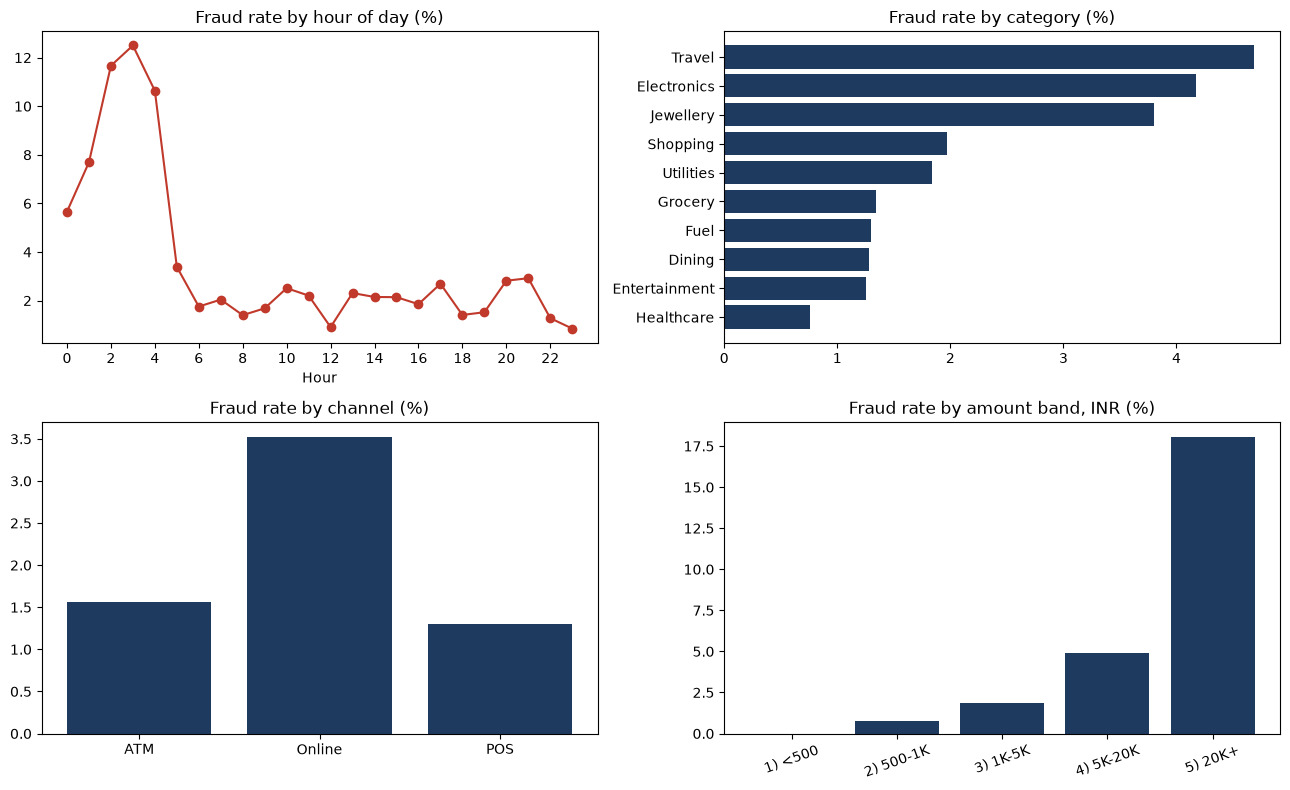

In [6]:
known_hour = txn.dropna(subset=['txn_hour'])
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

hr = known_hour.groupby('txn_hour')['is_fraud'].mean() * 100
ax[0, 0].plot(hr.index, hr.values, marker='o', color='#C0392B')
ax[0, 0].set_title('Fraud rate by hour of day (%)'); ax[0, 0].set_xlabel('Hour'); ax[0, 0].set_xticks(range(0, 24, 2))

ct = txn[txn['category'] != 'Unknown'].groupby('category')['is_fraud'].mean().sort_values() * 100
ax[0, 1].barh(ct.index, ct.values, color='#1F3A5F'); ax[0, 1].set_title('Fraud rate by category (%)')

ch = txn.groupby('payment_channel')['is_fraud'].mean() * 100
ax[1, 0].bar(ch.index, ch.values, color='#1F3A5F'); ax[1, 0].set_title('Fraud rate by channel (%)')

bands = txn[txn['amt_band'] != 'Unknown'].groupby('amt_band')['is_fraud'].mean() * 100
ax[1, 1].bar(bands.index, bands.values, color='#1F3A5F'); ax[1, 1].set_title('Fraud rate by amount band, INR (%)')
plt.setp(ax[1, 1].get_xticklabels(), rotation=20)

plt.tight_layout(); plt.savefig('charts/fraud_patterns.png', dpi=150); plt.show()

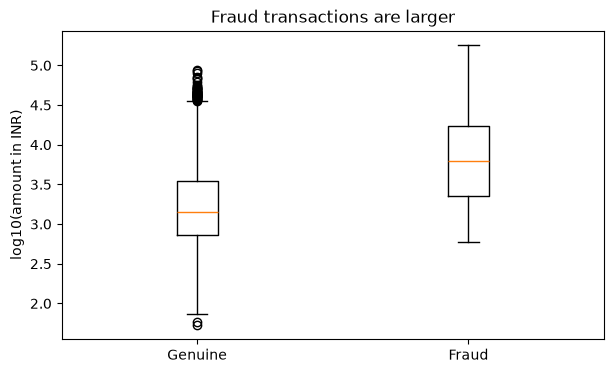

          count       mean    median
is_fraud                            
0          7751  3,447.468 1,434.540
1           181 16,948.125 6,266.570


In [7]:
# Amount distribution: fraud vs genuine (log scale because amounts are right-skewed)
valid = txn.dropna(subset=['amount'])
plt.figure(figsize=(7, 4))
plt.boxplot([np.log10(valid.loc[valid.is_fraud == 0, 'amount']), np.log10(valid.loc[valid.is_fraud == 1, 'amount'])])
plt.xticks([1, 2], ['Genuine', 'Fraud'])
plt.ylabel('log10(amount in INR)'); plt.title('Fraud transactions are larger')
plt.savefig('charts/amount_boxplot.png', dpi=150); plt.show()
print(valid.groupby('is_fraud')['amount'].agg(['count', 'mean', 'median']))

## 4. Is the channel difference real? (chi-square test)
*Why:* with only 182 frauds, a difference could be luck. The test asks: if channel and fraud were unrelated, how likely is a gap this big?
Null hypothesis: channel and fraud are independent. A small p-value (below 0.05) means we reject it.

In [8]:
table = pd.crosstab(txn['payment_channel'], txn['is_fraud'])
chi2, p, dof, _ = chi2_contingency(table)
print(table)
print(f'chi2={chi2:.1f}, p-value={p:.2e}')
print('Channel and fraud are related' if p < 0.05 else 'No strong evidence of a relationship')

is_fraud            0    1
payment_channel           
ATM               630   10
Online           3314  121
POS              3874   51
chi2=42.3, p-value=6.48e-10
Channel and fraud are related


## 5. Customer segmentation by spend
*Why:* segments (low / high spenders) are how product teams think about portfolios. We check whether higher spenders see more fraud.

**Careful:** spend includes the fraudulent amounts themselves, so this result is partly circular (a customer who was defrauded for a large amount looks like a high spender). Say this in the interview.

In [9]:
cust_level = (txn[txn['customer_known'] == 'Yes']
              .groupby('customer_id')
              .agg(txns=('txn_id', 'count'), spend=('amount', 'sum'), frauds=('is_fraud', 'sum'))
              .reset_index()
              .merge(cust[['customer_id', 'age_band', 'credit_band', 'city']], on='customer_id', how='left'))
cust_level['spend_segment'] = pd.qcut(cust_level['spend'], 4, labels=['Low', 'Mid-low', 'Mid-high', 'High'])
seg = cust_level.groupby('spend_segment', observed=True).agg(customers=('customer_id', 'count'),
                                                           txns=('txns', 'sum'), frauds=('frauds', 'sum'))
seg['fraud_rate'] = seg['frauds'] / seg['txns']
print(seg)
print('Customers with at least one fraud:', int((cust_level['frauds'] > 0).sum()))

               customers  txns  frauds  fraud_rate
spend_segment                                     
Low                  250  1496      16       0.011
Mid-low              249  1917      32       0.017
Mid-high             249  2143      41       0.019
High                 250  2417      92       0.038
Customers with at least one fraud: 161


## 6. Rule simulation - catch fraud without hurting genuine customers
Precision = share of flagged transactions that are really fraud. Recall = share of all fraud the rule catches.

In [10]:
def evaluate(name, mask):
    flagged = int(mask.sum()); caught = int(txn.loc[mask, 'is_fraud'].sum())
    genuine_hit = flagged - caught
    genuine_total = int((txn.is_fraud == 0).sum())
    return dict(rule=name, flagged=flagged, fraud_caught=caught,
                precision=caught / flagged if flagged else 0, recall=caught / fraud,
                genuine_hit_pct=genuine_hit / genuine_total)

amt = txn['amount']; hour = txn['txn_hour']; online = txn['payment_channel'] == 'Online'
rules = [evaluate('R1 amount >= 20,000', amt >= 20000),
         evaluate('R2 online & amount >= 5,000', online & (amt >= 5000)),
         evaluate('R3 online & hour 0-4', online & (hour <= 4)),
         evaluate('R4 online & >=5,000 & hour 0-4', online & (amt >= 5000) & (hour <= 4)),
         evaluate('R5 risky category & >=5,000', txn['category'].isin(['Travel', 'Electronics', 'Jewellery']) & (amt >= 5000))]
print(pd.DataFrame(rules).set_index('rule').round(3))

                                flagged  fraud_caught  precision  recall  \
rule                                                                       
R1 amount >= 20,000                 216            39      0.181   0.214   
R2 online & amount >= 5,000         686            64      0.093   0.352   
R3 online & hour 0-4                110            21      0.191   0.115   
R4 online & >=5,000 & hour 0-4       27             8      0.296   0.044   
R5 risky category & >=5,000        1342            83      0.062   0.456   

                                genuine_hit_pct  
rule                                             
R1 amount >= 20,000                       0.023  
R2 online & amount >= 5,000               0.080  
R3 online & hour 0-4                      0.011  
R4 online & >=5,000 & hour 0-4            0.002  
R5 risky category & >=5,000               0.161  


## 7. Conclusions 
1. Overall fraud rate: 2.28% (182 of 8,000 transactions)
2. Biggest risk signals (hour, channel, amount, category, city mismatch): night hours (0-4) at 9.7%, online channel at 3.5% vs POS 1.3%, tickets above Rs. 20K at 18%, categories Travel/Electronics/Jewellery, and city mismatch at 4.0% vs 2.1%.
3. Signals that did NOT matter (age, credit limit): age band and credit limit band, fraud rates were similar across groups, so they should not be used as rules.
4. Recommended rule and its trade-off: step-up authentication for online transactions of Rs. 5,000 or more catches about 35% of fraud but touches about 8% of genuine transactions. A stricter night rule is more precise but catches only about 4% of fraud.
5. Limitations: simulated data, only 182 fraud cases, and rules were tested on the same data they were found in (no train/test split).